# Google contrail forecasts

Google contrail forecasts are available through the [Google Contrails API](https://developers.google.com/contrails/v1/forecast-description#ml-based_model). Access is free but requires an [API key](https://developers.google.com/contrails/v1/getting-started).

This notebook shows
1. How to access Google contrail forecasts with asynchronous HTTP requests (convenient when requesting large amounts of data)
2. How to preprocess Google contrail forecasts into the format expected by ContrailBench PCR benchmarks

## Accessing Google forecasts

In [12]:
import datetime
import os

import aiohttp
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr

The Google Contrails API accepts both forecast time and flight level as query parameters. However, omitting the flight level parameter to retrieve all available flight levels at once often leads to better performance when retrieving large amounts of data. The Google contrail forecast is probabilistic, and ContrailBench uses the `persistent_formation_probability` field for PCR benchmarks.

In [13]:
time = datetime.datetime(2024, 6, 1, 0)

url = "https://contrails.googleapis.com/v2/grids"
params = {"time": time.isoformat(), "data": "persistent_formation_probability"}
headers = {"x-goog-api-key": os.environ["GOOGLE_API_KEY"]}

async with (
    aiohttp.ClientSession(raise_for_status=True) as session,
    session.get(url, params=params, headers=headers) as resp,
):
    content = await resp.read()

The Google Contrails API returns gridded forecasts as netCDF file. These can be opened using xarray after saving to disk.

In [6]:
with open("forecast.nc", "wb") as f:
    f.write(content)

ds = xr.open_dataset("forecast.nc")

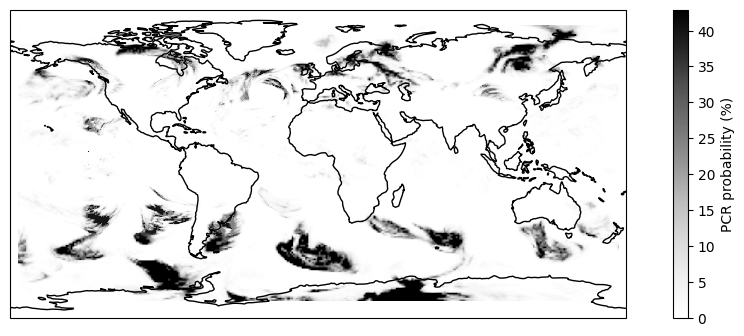

In [10]:
plt.figure(figsize=(12, 4))
ax = plt.subplot(111, projection=ccrs.PlateCarree())
im = ax.pcolormesh(
    ds["longitude"],
    ds["latitude"],
    ds["persistent_formation_probability"].sel(flight_level=350).squeeze().T,
    shading="nearest",
    cmap="Greys",
    transform=ccrs.PlateCarree(),
)
plt.colorbar(im, ax=ax, label="PCR probability (%)")
ax.coastlines();

## Preprocessing Google contrails forecasts

The probability field provided by the Google Contrails API can be used directly in ContrailBench PCR benchmarks with no additional preprocessing beyond standardizing variables names and units.

In [9]:
ds["ppcr"] = ds["persistent_formation_probability"] / 100.0
processed = ds[["ppcr"]]

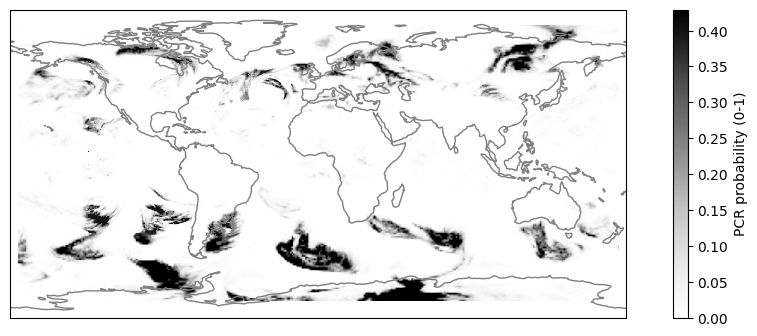

In [11]:
plt.figure(figsize=(12, 4))
ax = plt.subplot(111, projection=ccrs.PlateCarree())
im = ax.pcolormesh(
    processed["longitude"],
    processed["latitude"],
    processed["ppcr"].sel(flight_level=350).squeeze().T,
    shading="nearest",
    cmap="Greys",
    transform=ccrs.PlateCarree(),
)
plt.colorbar(im, ax=ax, label="PCR probability (0-1)")
ax.coastlines(color="gray");